# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.


### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.


In [1]:
# Imports
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.metrics import roc_auc_score, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, roc_curve, auc, precision_recall_curve
from sklearn.dummy import DummyClassifier
from pandas.core.api import DataFrame
from statsmodels.stats.outliers_influence import variance_inflation_factor


#warnings.filterwarnings("ignore", category=UserWarning)
#sns.set_theme(style="whitegrid", context="notebook")
#plt.rcParams["figure.figsize"] = (8, 5)


### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer:** *According to the PDF,  the data are related to **17 campaigns** that occurred between May 2008 and November 2010.*

### Problem 2: Read in the Data


In [3]:
df = pd.read_csv("data/bank-additional-full.csv", sep=";")
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# **EDA**

In [4]:
print("Shape: ", df.shape)
print("Data Types: ")
print(df.dtypes)
print("Missing Values: ")
print(df.isna().sum().sum())

Shape:  (41188, 21)
Data Types: 
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object
Missing Values: 
0


<div class="alert alert-info">

#### Data contains 41,188 Rows and 21 Columns (including the Target Variable)

#### Data types
*   There are 11 Categorical Columns - including the Target Variable. We need to do **unique values and distribution** in each of them to determine **encoding** options later.
*   10 Numeric columns - We have to evaluate the distribution on them for **scaling** determinations.


    
#### There are No NULL Values in the data set which could mean:
1) Data is very **$\color{blue}{clean \space and \space complete}$** OR
2) Could be that they are **$\color{red}{already \space replaced}$** with "NA" or "Other" or "Unknown" labels
#### We need to look at **Unique values** of the Categorical columns to determine next steps and how to handle them for Encoding.
    
</div>

### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

Input variables:
### Bank client data:
1. age (numeric)
2. job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3. marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4. education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5. default: has credit in default? (categorical: 'no','yes','unknown')
6. housing: has housing loan? (categorical: 'no','yes','unknown')
7. loan: has personal loan? (categorical: 'no','yes','unknown')

### Related with the last contact of the current campaign:
8. contact: contact communication type (categorical: 'cellular','telephone')
9. month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10. day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11. duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

### Other Attributes:
12. campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13. pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14. previous: number of contacts performed before this campaign and for this client (numeric)
15. poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

### social and economic context attributes
16. emp.var.rate: employment variation rate - quarterly indicator (numeric)
17. ons.price.idx: consumer price index - monthly indicator (numeric)
18. cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19. euribor3m: euribor 3 month rate - daily indicator (numeric)
20. nr.employed: number of employees - quarterly indicator (numeric)

### Output variable (desired target):
21. y - has the client subscribed a term deposit? (binary: 'yes','no')



## **Numerical Features Analysis**

In [5]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


##### Based on the note above, **"Duration"** should be dropped from the df before we start modeling as duration will not be known before a call is placed - Keeping it will cause **Leakage** for the target variable.

##### Based on the data description above, We also see the default value for lot of categorical column is "Unknown". Next we need to an equivalent "ISNULL" analysis but for Unknown values.

#### Describe Results
* **Duration** column seems to have one or few outliers - Mean = 258, but max almost 20X of the mean. As we are going to drop the column - we don't need to handle the outliers.
* **pdays** default value of 999 used when the client was never previously contacted is messing up all the statistics. We have to handle to column while feature engineering - otherwise it will impact model outcomes - Standard Scaling might help handle it.
* **campaign** column also seems to have some outliers - from the big jump between 75th percentile to max. Needs further analysis - Standard Scaling might help handle it.
* **previous** column also looks weird. Based on the definition and the percentile distribution we are seeing, it looks like most of the rows have 0 value - Standard Scaling might help handle it.

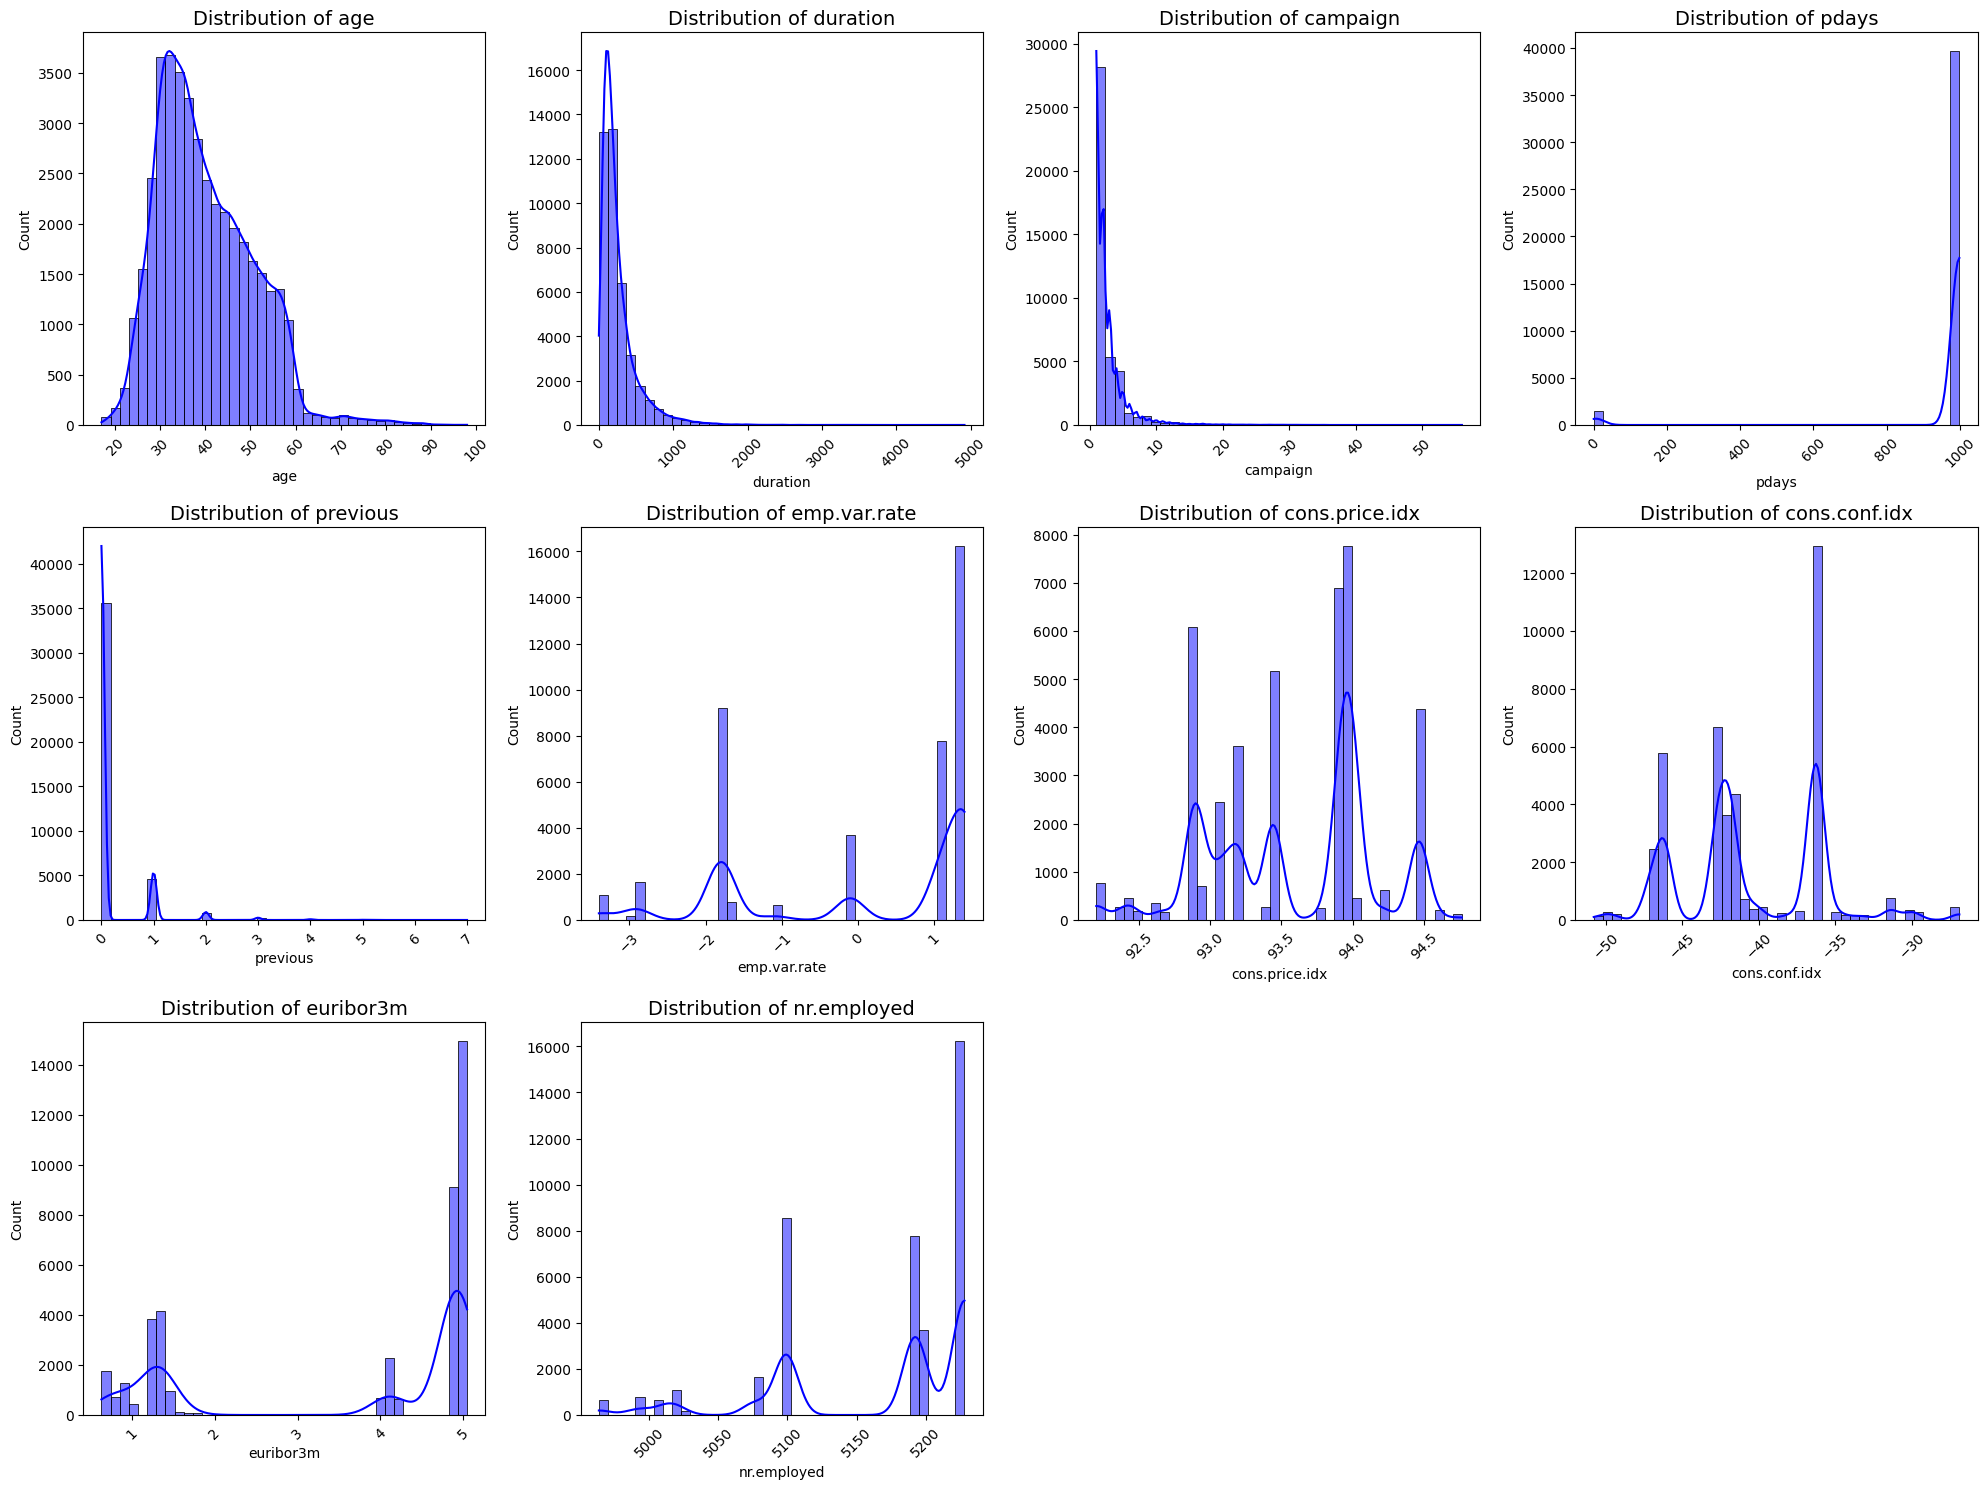

In [6]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

def create_dist_histplot(data, feature_name, ax, title):
    sns.histplot(data=data, x=feature_name, bins=40, kde=True, ax=ax, color='blue', edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Count')
    ax.set_xlabel(feature_name)
    ax.tick_params(axis='x', rotation=45)

num_numerical_cols = len(numerical_cols)
n_rows = (num_numerical_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):
    if i < len(axes):
        create_dist_histplot(df, feature, axes[i], f'Distribution of {feature}')

# Remove any unused subplots
for j in range(num_numerical_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Distribution Analysis:
* Age has a **decent** normal distribution. Majortiy of the data is between 30 and 55
* **"Duration", "Campaign", "Previous", "pdays"** are heavily skewed towards the edges.
* Rest of the features are sparsely distributed.



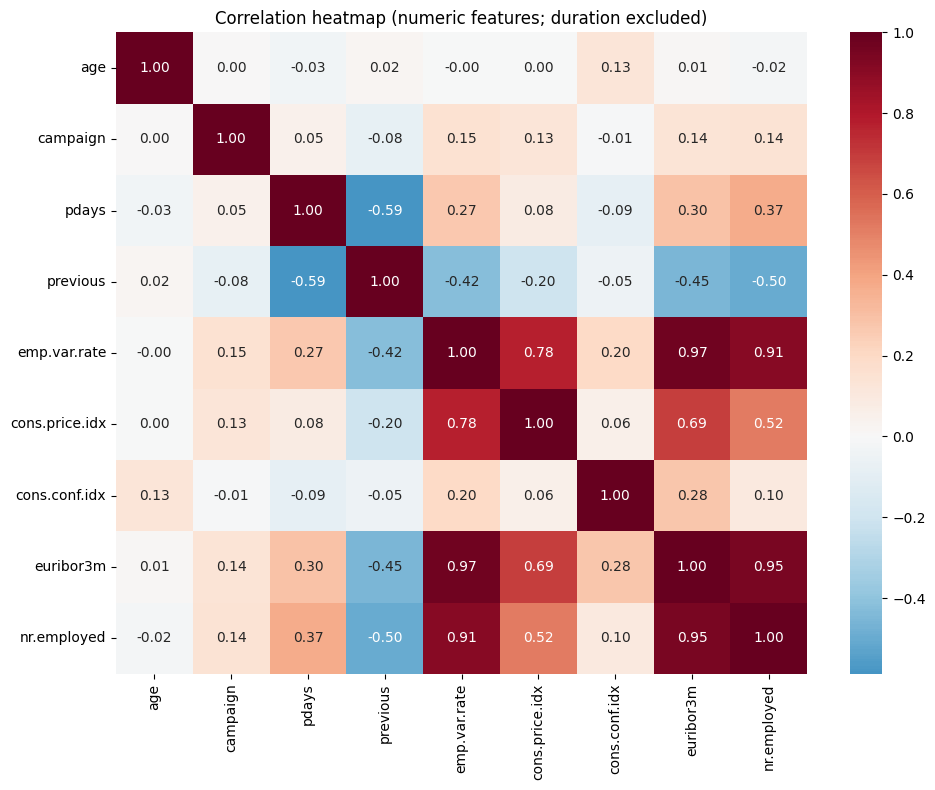

In [7]:
numerical_cols_upd = df.select_dtypes(include=["int64","float64"]).columns.drop("duration").tolist()
corr = df[numerical_cols_upd].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation heatmap (numeric features; duration excluded)")
plt.tight_layout()
plt.show()


### Correlation Coefficients:
* Socia Economic Attributes seem to be highly correlated with each other.
  * **emp.var.rate** is very highly correlated with **euribor3m** and **nr.employed**  
  * **emp.var.rate** is also highly correlated with **cons.price.idx**
  * **cons.price.idx** is also highly correlated with **euribor3m**

When we get to the modeling, we should keey **ONLY ONE** of these economic attributes and drop all others.

#### To Determine which one to drop


1. Check the Variance Inflation Factor (VIF). A VIF above 5 or 10 often indicates problematic multicollinearity.
2. Check for Correlation with the Target Variable.




In [8]:
features_to_check = df[numerical_cols_upd]

vif_data = pd.DataFrame()
vif_data['feature'] = features_to_check.columns
vif_data['VIF'] = [variance_inflation_factor(features_to_check.values, i) for i in range(len(features_to_check.columns))]

display(vif_data.sort_values(by='VIF', ascending=False))

# Convert target to numeric for correlation calculation
y_numeric = (df['y'] == 'yes').astype(int)

# Calculate correlation with target for the features in question
corrs = {}
for col in ['euribor3m', 'cons.conf.idx', 'emp.var.rate', 'cons.price.idx', 'nr.employed']:
    correlation, _ = stats.pointbiserialr(df[col], y_numeric)
    corrs[col] = correlation

corr_series = pd.Series(corrs).sort_values(ascending=False)
print("Correlation with target (y):")
display(corr_series)

,feature,VIF
8,nr.employed,26719.49
5,cons.price.idx,22521.66
7,euribor3m,226.23
6,cons.conf.idx,120.06
2,pdays,44.35
4,emp.var.rate,28.91
0,age,16.05
3,previous,2.00
1,campaign,1.91


Correlation with target (y):


,0
cons.conf.idx,0.05
cons.price.idx,-0.14
emp.var.rate,-0.30
euribor3m,-0.31
nr.employed,-0.35


#### VIF is proving the multicollinearity we saw with the correlation matrix. We should definitely drop **nr.employed** and **cons.price.idx** given their massive VIF.

Between euribor3m, cons.conf.idx and emp.var.rate:
*  **euribor3m and emp.var.rate** have high correlation with the Target variable. So either one can stay while we drop the other economic features.
*  For now, I will prefer **euribor3m** as it is a daily indicator over **emp.var.rate** which is a quarterly indicator.

## **Categorical Features Analysis**

In [9]:
category_cols = df.select_dtypes(include=["object"]).columns.drop("y")
unknown_counts = pd.Series({c: (df[c] == "unknown").sum() for c in category_cols}).sort_values(ascending=False)
unknown_counts = unknown_counts[unknown_counts > 0]
unknown_percentages = (unknown_counts / len(df) * 100).round(2)

summary_unknown_df = pd.DataFrame({
    'Unknown Count': unknown_counts,
    'Percentage': unknown_percentages
})
summary_unknown_df

,Unknown Count,Percentage
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


<div style="background-color: #5d8aa8; padding: 10px; border: 1px solid #dfb5b4; color: white;">

<h4 style="margin-top:0;"><strong>21%</strong> of the "Default" column is Unknown.</h4>

One Hot Encoding might help handle it. OHE will create a "Unknown" feature.

For rest of the columns we might be ok to keep the Unknowns as is.

</div>

In [10]:
unique_counts = df[category_cols].nunique().reset_index()
unique_counts.columns = ['Feature', 'Unique_Values']

print("Unique Values Summary:")
print(unique_counts)

Unique Values Summary:
       Feature  Unique_Values
0          job             12
1      marital              4
2    education              8
3      default              3
4      housing              3
5         loan              3
6      contact              2
7        month             10
8  day_of_week              5
9     poutcome              3


#### None of the categorical columns have a lot of unique values. We might be ok to do **One Hot Encoding** for them.

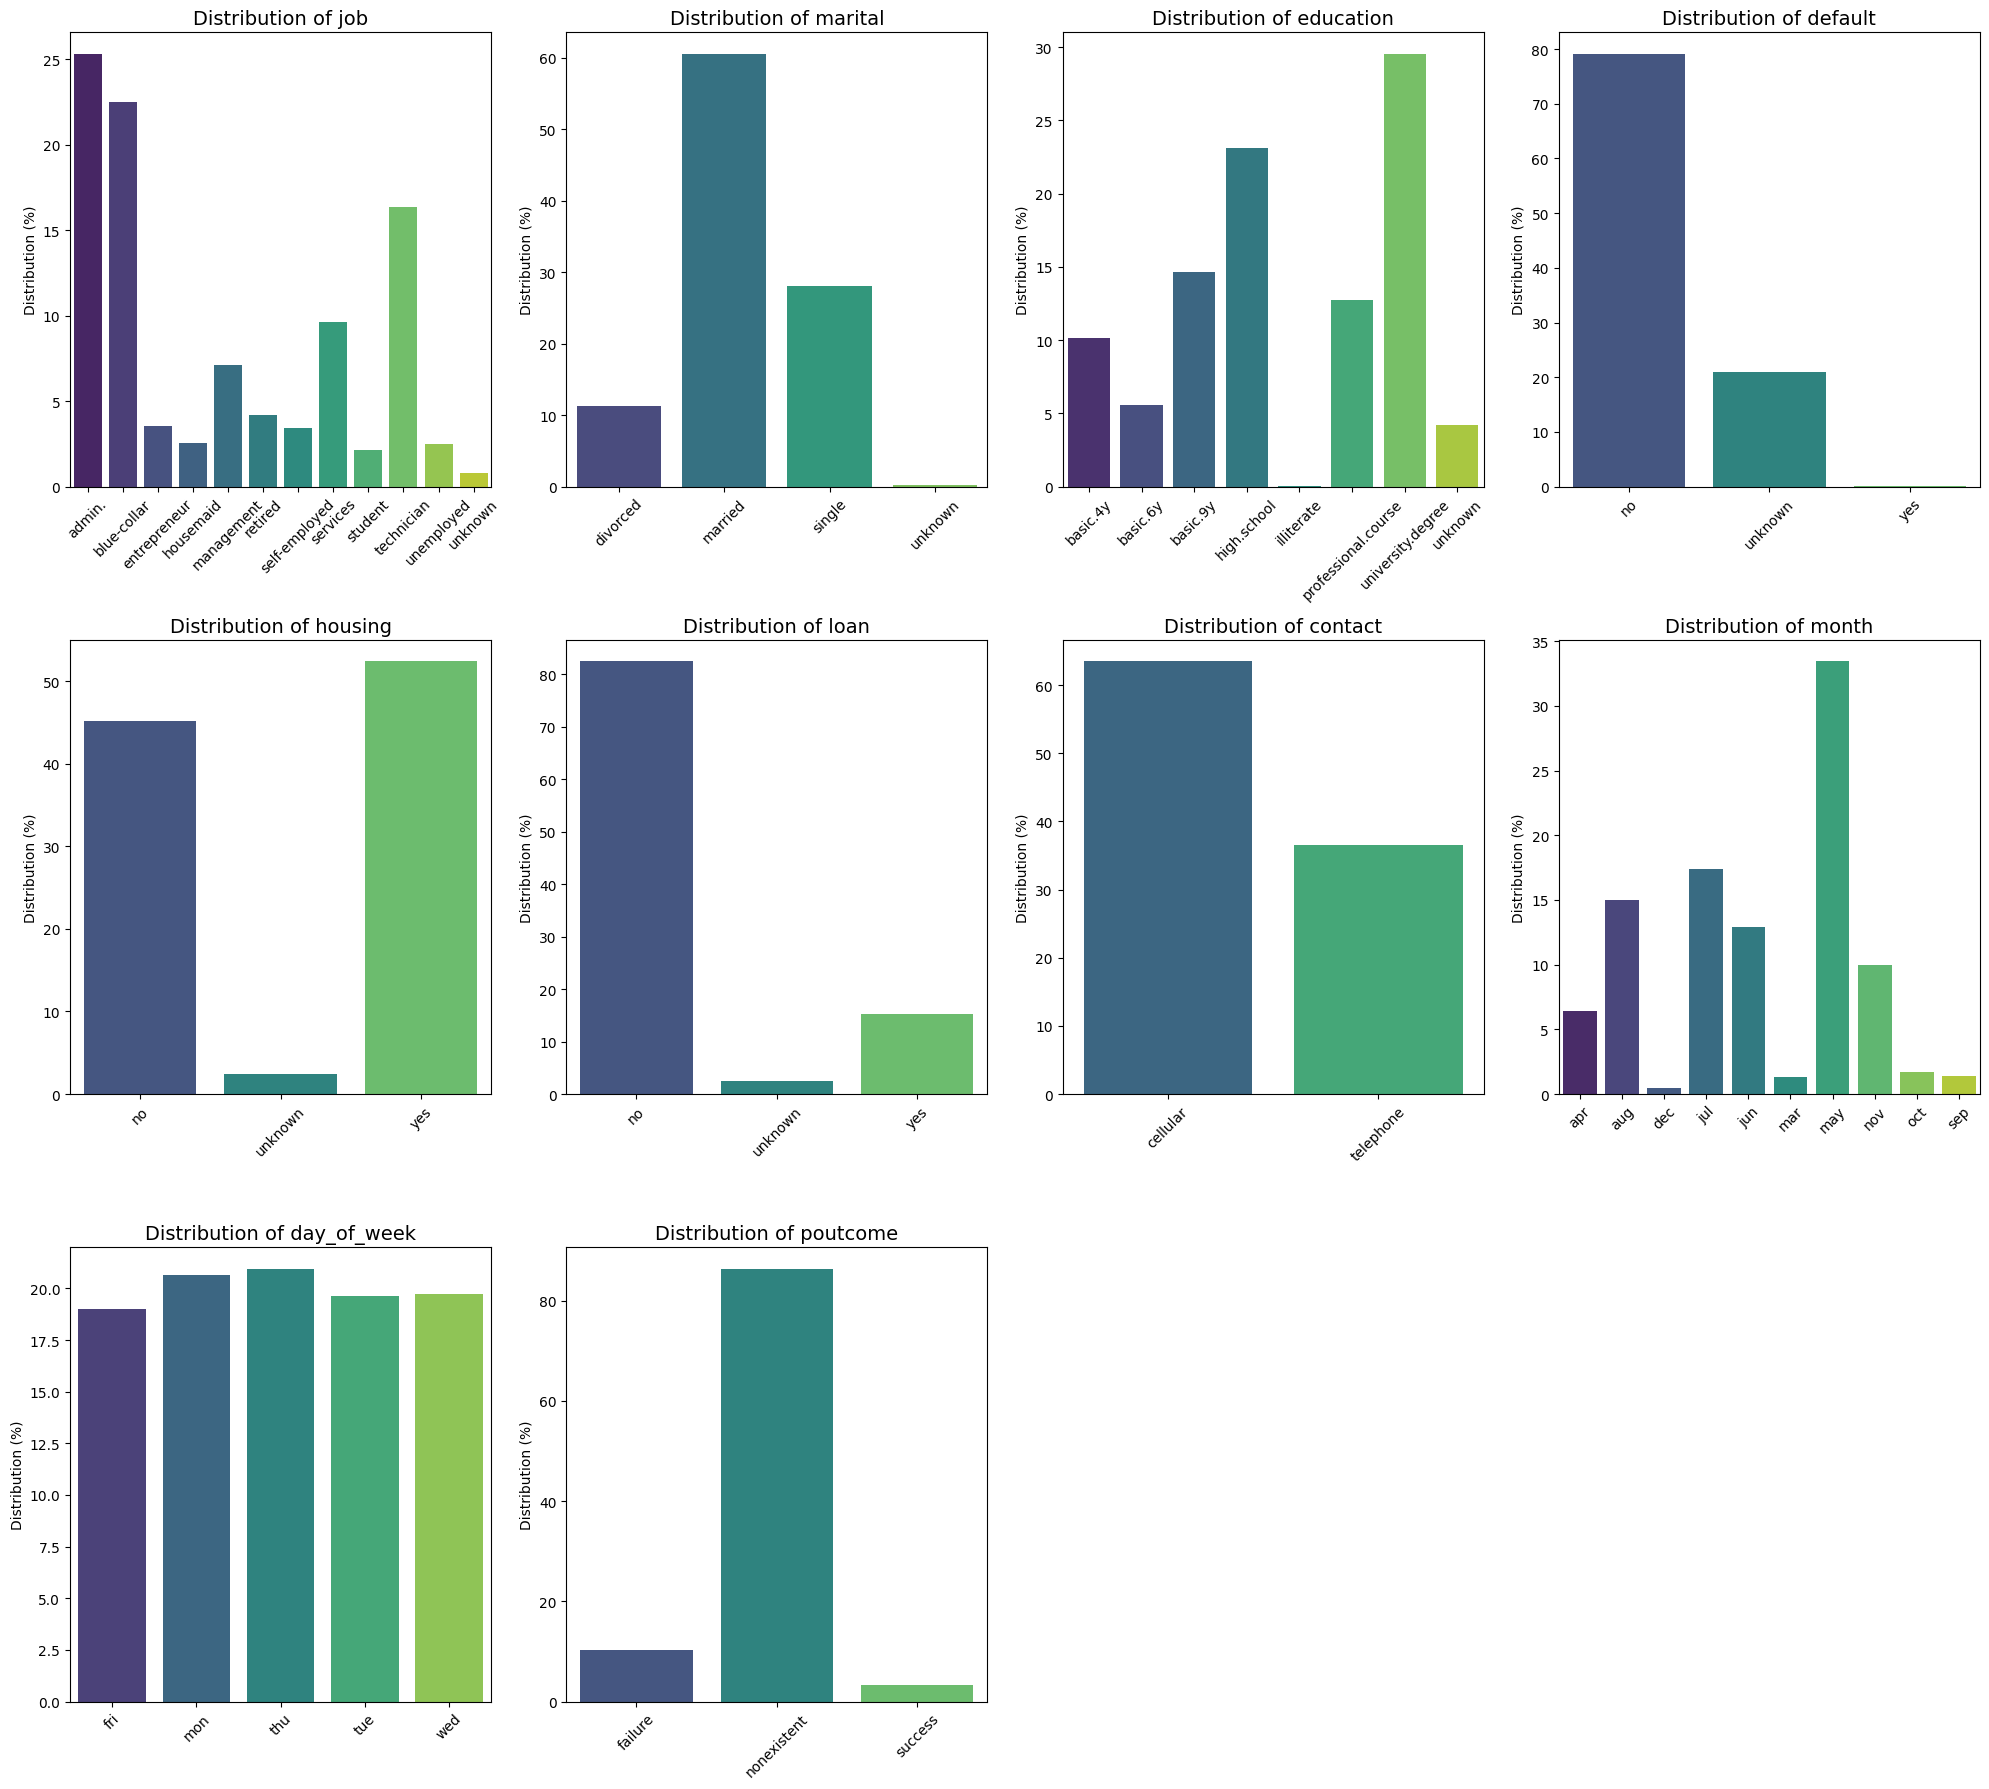

In [11]:
stats_list=[]
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df['y_numeric'] = df['y'].map({'yes': 1, 'no': 0})

for col in category_cols:
    # Use size() to count occurrences of each category
    stats = df.groupby(col)['y_numeric'].agg(['count','mean']).reset_index()
    stats.columns = ['Value', 'Count', 'Mean']
    stats['Feature'] = col
    total = stats['Count'].sum()
    stats['Percentage'] = (stats['Count'] / total * 100).round(2)
    stats_list.append(stats)

stats_df = pd.concat(stats_list, ignore_index=True)

def create_dist_barplot(data, feature_name, ax, title):
    feature_data = data[data['Feature'] == feature_name]
    sns.barplot(data=feature_data, x='Value', y='Percentage', hue='Value', ax=ax, palette='viridis', legend=False)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Distribution (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(3, 4, figsize=(20, 18))
axes = axes.flatten()

for i, feature in enumerate(category_cols):
    create_dist_barplot(stats_df, feature, axes[i], f'Distribution of {feature}')

for j in range(len(category_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Categorical Columns Distribution by Y target variable

Nothing new stands out from what we previously discovered.

## **Target Feature Analysis**

**Class imbalance**

/tmp/ipykernel_1861/185037883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="y", order=["no", "yes"], palette="Set2", ax=ax)


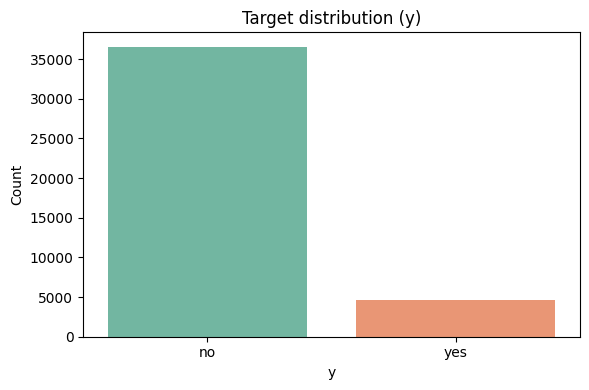

Class proportions:
 y
no    0.89
yes   0.11
Name: proportion, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="y", order=["no", "yes"], palette="Set2", ax=ax)
ax.set_title("Target distribution (y)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print("Class proportions:\n", df["y"].value_counts(normalize=True).round(4))

#### Target Variable is **imbalanced**. When we do modeling, we have to **balance the class weights during hyper parameter tuning**

# **Problem 4: Business objective**

Predict **long-term deposit subscription** (y) using the available numerical and categorical attributes so the bank can **prioritize** the **right contacts** to **optimize spend** and maximize **subscriptions**.


---




# **Problem 5: Engineering features**

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

### **BANK ONLY FEATURES**

#### ***Steps:***
1. Bank-only columns:  `age` to `loan`.
2. Feature Engineering - `One Hot Encoder` and `Standard Scaler`
3. Train / Test Split
4. Fit Model - Basic Logistic Regression
5. Model Accuracy

In [13]:
# Bank Only Columns
BANK_ONLY_FEATURES = ["age", "job", "marital", "education", "default", "housing", "loan"]
type(BANK_ONLY_FEATURES)

list

In [14]:
# Feature Engineering Pipeline
def build_preprocessor(feature_list, df):
    numeric = df[feature_list].select_dtypes(include=["int64","float64"]).columns.tolist()
    categorical = df[feature_list].select_dtypes(include=["object"]).columns.tolist()
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    return ColumnTransformer(
        [
            ("num", StandardScaler(), numeric),
            ("cat", ohe, categorical),
        ]
    )
# Preprocess Bank Only Features
pre_bank = build_preprocessor(BANK_ONLY_FEATURES, df)

Classification Report for Bank-only Features:
              precision    recall  f1-score   support

          no       0.92      0.58      0.71      7310
         yes       0.16      0.62      0.25       928

    accuracy                           0.58      8238
   macro avg       0.54      0.60      0.48      8238
weighted avg       0.84      0.58      0.66      8238



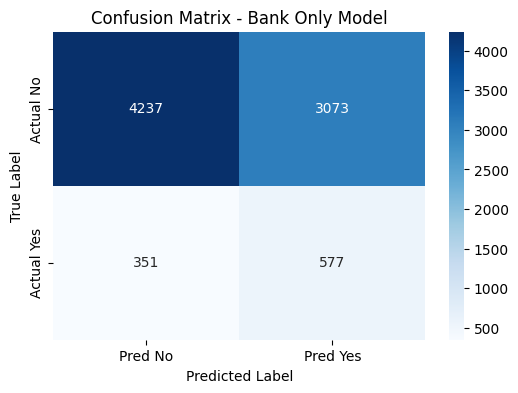

Precision: 0.1581
Recall:    0.6218
F1 Score:  0.2521
Accuracy:  0.5844
ROC-AUC: 0.6498


In [15]:
# Train / Test Split
#     - 80/20 Split
#     - Stratify for target variable imbalance. Split training and testing sets to have same proportion of 'yes' and 'no' as the original data.
X_bank = df[BANK_ONLY_FEATURES]
y_bank = df["y_numeric"]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bank, y_bank, test_size=0.2, random_state=42, stratify=y_bank)
# Data Pipeline - Preprocess and Instantiate Log Regression
bo_pipe = Pipeline([
    ("prep", pre_bank),
    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)) # Class_Weight Balanced
])
# Filt
bo_pipe.fit(Xb_train, yb_train)

# Predict on the test set
yb_pred = bo_pipe.predict(Xb_test)

# Calculate ROC-AUC Score for the Bank-only Features
yb_probs = bo_pipe.predict_proba(Xb_test)[:, 1]
bank_roc_auc = roc_auc_score(yb_test, yb_probs)

# Classification Report (Precision, Recall, F1)
print("Classification Report for Bank-only Features:")
print(classification_report(yb_test, yb_pred, target_names=['no', 'yes']))

# 2. Confusion Matrix
cm = confusion_matrix(yb_test, yb_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - Bank Only Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Specific Metric Scores
print(f"Precision: {precision_score(yb_test, yb_pred):.4f}")
print(f"Recall:    {recall_score(yb_test, yb_pred):.4f}")
print(f"F1 Score:  {f1_score(yb_test, yb_pred):.4f}")
print(f"Accuracy:  {accuracy_score(yb_test, yb_pred):.4f}")
print(f"ROC-AUC: {bank_roc_auc:.4f}")

### **Bank Only Features - Log Regression Model Results**

* Model has very **moderate accuracy** (58%) - just better than the coin toss (50%). I guess, we need to ad more features to improve accuracy.
* Model has decent **recall** (62%) - it is successfully able to identify 62% of all actual subscribers -- good news for marketing, but could improve a a lot.
* Model has very poor **precision** (16%) - it is producing a lot of false positives - meaning our targetting is poor and we are spending money on calling the wrong people.
* ROC-AUC is 0.65 - Similar to Accuracy - Model is decent, but we need add more features or try other classification models to improve it.


---



### **DUMMY CLASSIFIER**


In [16]:
# Create and evaluate a Baseline (Dummy Classifier - most frequent)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(Xb_train, yb_train)

# Predict
dummy_pred = dummy.predict(Xb_test)

print(f"Dummy Baseline Precision: {precision_score(yb_test, dummy_pred):.4f}")
print(f"Dummy Baseline Recall:    {recall_score(yb_test, dummy_pred):.4f}")
print(f"Dummy Baseline F1 Score:  {f1_score(yb_test, dummy_pred):.4f}")
print(f"Dummy Baseline Accuracy:  {accuracy_score(yb_test, dummy_pred):.4f}")
print(f"Dummy Baseline ROC-AUC:   {roc_auc_score(yb_test, dummy.predict_proba(Xb_test)[:, 1]):.4f}")

Dummy Baseline Precision: 0.0000
Dummy Baseline Recall:    0.0000
Dummy Baseline F1 Score:  0.0000
Dummy Baseline Accuracy:  0.8874
Dummy Baseline ROC-AUC:   0.5000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### The Dummy Classifier has very **high accuracy (89%)** compared to our "Bank Only Features" model because of the class imbalance of the target variable.....predicting more "No" is just bumping up its accuracy. Whereas our "Bank Only Model" is really traying to predict the "Actual Subscribers".


---



### **Trying All the Features for Logistic Regression**

In [19]:
# Extracting all the features except a) Target variables and b) Duration, c) Keep only one of the highly correlated columns "euribor3m" and remove others
FULL_FEATURES = [c for c in df.columns if c not in ("y", "y_numeric", "duration","emp.var.rate", "cons.price.idx", "cons.conf.idx", "nr.employed")]

# Preprocess All Features
pre_full = build_preprocessor(FULL_FEATURES, df)

X = df[FULL_FEATURES]
y = df["y_numeric"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_svm, _, y_svm, _ = train_test_split(X_train, y_train, train_size=10000, random_state=42, stratify=y_train)

X_train.shape, X_test.shape, X_svm.shape, y_train.shape, y_test.shape, y_svm.shape

((32950, 15), (8238, 15), (10000, 15), (32950,), (8238,), (10000,))

Classification Report for All Features:
              precision    recall  f1-score   support

          no       0.95      0.82      0.88      7310
         yes       0.32      0.68      0.44       928

    accuracy                           0.80      8238
   macro avg       0.64      0.75      0.66      8238
weighted avg       0.88      0.80      0.83      8238



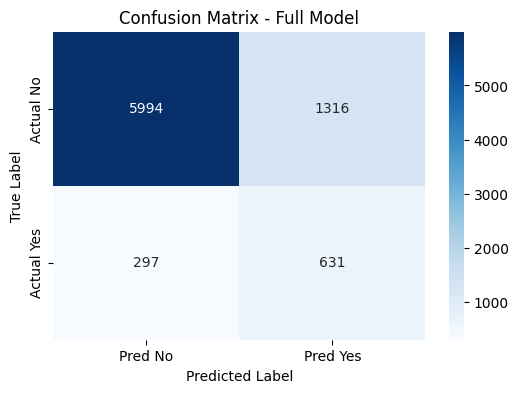

Precision: 0.3241
Recall:    0.6800
F1 Score:  0.4390
Accuracy:  0.8042
ROC-AUC: 0.7975


In [20]:
# Data Pipeline - Preprocess and Instantiate Log Regression
full_log_pipe = Pipeline([
    ("prep", pre_full),
    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)) # Class_Weight Balanced
])
# Filt
full_log_pipe.fit(X_train, y_train)

# Predict on the test set
yf_pred = full_log_pipe.predict(X_test)

# Calculate ROC-AUC Score for the Bank-only Features
yf_probs = full_log_pipe.predict_proba(X_test)[:, 1]

# Classification Report (Precision, Recall, F1)
print("Classification Report for All Features:")
print(classification_report(y_test, yf_pred, target_names=['no', 'yes']))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, yf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - Full Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Specific Metric Scores
print(f"Precision: {precision_score(y_test, yf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, yf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, yf_pred):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, yf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, yf_probs):.4f}")

### **All Features - Log Regression Model Results**

* **Model Accuracy** (80%) - Gone up from the "Bank Only" baseline model (58%) - meaning the additional features definitey help with predicting the outcome.
* Model has decent **recall** (68%) - Not a big improvement compared to the baseline model (62%). Need to try with other models and hyper parameter tuning.
* **Precision** (32%) - Still poor but a big improvement compared to the baseline model (16%).
* **ROC-AUC** is 0.80
---

## **TRY FITTING MULTIPLE MODELS**

Baseline - No Hyper Parameters

In [21]:
# Function to fit a model and calculate model performance metrics
def score_model(pipe, X_tr, y_tr, X_te, y_te):
    t0 = time.perf_counter()
    pipe.fit(X_tr, y_tr)
    fit_time = time.perf_counter() - t0
    t1 = time.perf_counter()
    pred_tr = pipe.predict(X_tr)
    pred_te = pipe.predict(X_te)
    # Note: SVC needs probability=True to use predict_proba
    if hasattr(pipe, 'predict_proba'):
        pred_te_probs = pipe.predict_proba(X_te)[:, 1]
        roc = roc_auc_score(y_te, pred_te_probs)
    else:
        roc = None
    predict_time = time.perf_counter() - t1
    return {
        "train_time_s": fit_time,
        "predict_time_s": predict_time,
        "train_acc": accuracy_score(y_tr, pred_tr),
        "test_acc": accuracy_score(y_te, pred_te),
        "precision": precision_score(y_te, pred_te),
        "recall": recall_score(y_te, pred_te),
        "f1_score": f1_score(y_te, pred_te),
        "roc_auc": roc,
    }

# Define model configurations
models_to_run = [
    ("LogisticRegression", Pipeline([("prep", pre_full), ("lr", LogisticRegression(max_iter=5000, random_state=42))]), X_train, y_train),
    ("KNN (k=5)", Pipeline([("prep", pre_full), ("knn", KNeighborsClassifier())]), X_train, y_train),
    ("DecisionTree", Pipeline([("prep", pre_full), ("dtc", DecisionTreeClassifier(random_state=42))]), X_train, y_train),
    ("SVM", Pipeline([("prep", pre_full), ("svm", SVC(random_state=42))]), X_svm, y_svm)
]

model_perf = []
for name, pipe, xtr, ytr in models_to_run:
    print(f"Running {name}...")
    results = score_model(pipe, xtr, ytr, X_test, y_test)
    model_perf.append({"Model": name, **results})

compare_df = pd.DataFrame(model_perf)
compare_df

Running LogisticRegression...
Running KNN (k=5)...
Running DecisionTree...
Running SVM...


,Model,train_time_s,predict_time_s,train_acc,test_acc,precision,recall,f1_score,roc_auc
0,LogisticRegression,0.45,0.25,0.90,0.90,0.70,0.20,0.31,0.80
1,KNN (k=5),0.15,16.31,0.91,0.89,0.56,0.24,0.34,0.72
2,DecisionTree,0.39,0.16,1.00,0.84,0.31,0.34,0.33,0.62
3,SVM,4.08,8.41,0.90,0.90,0.69,0.19,0.30,NaN


### **Model Comparison Analysis**

* **Leaders**: Logistic Regression & SVM both achieved a high test accuracy of 90%. Logistic Regression has a strong ROC-AUC of 0.80, indicating it's the best overall at ranking the probability of a subscription. Logistic Regression has the highest precision (0.70), meaning when it predicts a 'yes', it is correct more often than the others, but it has one of the lowest recall (0.20) - indicating the model's poor ability to identify true subscribers.

* **Overfitter** : Decision Tree model shows a classic case of overfitting (100% training accuracy) but its test accuracy is the lowest of all (84%). Both its precision / recall are very low (0.31 / 0.34), meaning it generates many false alarms and it is bad in identifying true intent customers.

* **KNN**: Has the 2nd highest ROC-AUC after Logistic Regression meaning it's slightly better at finding actual subscribers, but took the longest time to predict (over 16 seconds) because it must compare each new data point to the entire training set - which is something we can tune with hyper parameter tuning and see if it improves.

* **Execution Time**: The SVM and KNN models are significantly slower than Logistic Regression and Decision Trees.

### If you need a fast, real-time prediction system, **Logistic Regression** seems to offer the best balance of speed and overall predictive power (ROC-AUC).


---


## **HYPER PARAMETER TUNING WITH GRID SEARCH**


In [22]:
# Hyper Parameters for Log Regression, KNN, Decision Tree and SVM
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
param_grid_lr = {"clf__C": [0.01, 0.1, 1.0, 10.0],"clf__penalty": ["l2"],"clf__solver": ["lbfgs"],"clf__class_weight": ["balanced"]}
param_grid_knn = {"clf__n_neighbors": [3, 11, 31, 51],"clf__weights": ["uniform", "distance"],"clf__p": [1, 2]}
param_grid_dt = {"clf__max_depth": [4, 8, 12, None],"clf__min_samples_leaf": [1, 5, 20],"clf__class_weight": ["balanced"]}
param_grid_svc = {"clf__C": [0.1, 1.0, 10.0],"clf__gamma": ["scale", 0.01, 0.001],"clf__class_weight": ["balanced"]}

#Pipelines for each model
pipe_lr = Pipeline([("prep", pre_full),("clf", LogisticRegression(max_iter=5000, random_state=42))])
pipe_knn = Pipeline([("prep", pre_full), ("clf", KNeighborsClassifier())])
pipe_dt = Pipeline([("prep", pre_full), ("clf", DecisionTreeClassifier(random_state=42))])
pipe_svc = Pipeline([("prep", pre_full),("clf", SVC(kernel="rbf", probability=True, random_state=42))])

# GridSearchCV
gs_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)
gs_knn = GridSearchCV(pipe_knn, param_grid_knn, scoring="roc_auc", cv=cv, n_jobs=-1)
gs_dt = GridSearchCV(pipe_dt, param_grid_dt, scoring="roc_auc", cv=cv, n_jobs=-1)
gs_svc = GridSearchCV(pipe_svc, param_grid_svc, scoring="roc_auc", cv=cv, n_jobs=-1)

# Starting the clock and Fitting the Models
# Logistic Regression
lr_t0 = time.perf_counter()
gs_lr.fit(X_train, y_train)
lr_time = time.perf_counter() - lr_t0
#KNN
knn_t0 = time.perf_counter()
gs_knn.fit(X_train, y_train)
knn_time = time.perf_counter() - knn_t0
#Decision Tree
dt_t0 = time.perf_counter()
gs_dt.fit(X_train, y_train)
dt_time = time.perf_counter() - dt_t0
#SVM
svm_t0 = time.perf_counter()
gs_svc.fit(X_svm, y_svm)
svc_time = time.perf_counter() - svm_t0

# Model Performance Outputs
# Logistic Regression
print("Logistic — best CV ROC-AUC:", round(gs_lr.best_score_, 4), "wall time (s):", round(lr_time, 2))
print("Best params:", gs_lr.best_params_)
print("----------------------------")
#KNN
print("KNN — best CV ROC-AUC:", round(gs_knn.best_score_, 4), "wall time (s):", round(knn_time, 2))
print("Best params:", gs_knn.best_params_)
print("----------------------------")
#Decision Tree
print("Tree — best CV ROC-AUC:", round(gs_dt.best_score_, 4), "wall time (s):", round(dt_time, 2))
print("Best params:", gs_dt.best_params_)
print("----------------------------")
#SVM
print("SVC (10k) — best CV ROC-AUC:", round(gs_svc.best_score_, 4), "wall time (s):", round(svc_time, 2))
print("Best params:", gs_svc.best_params_)
print("----------------------------")

Logistic — best CV ROC-AUC: 0.7873 wall time (s): 10.77
Best params: {'clf__C': 1.0, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
----------------------------
KNN — best CV ROC-AUC: 0.7701 wall time (s): 402.3
Best params: {'clf__n_neighbors': 51, 'clf__p': 2, 'clf__weights': 'uniform'}
----------------------------
Tree — best CV ROC-AUC: 0.7834 wall time (s): 15.02
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 4, 'clf__min_samples_leaf': 20}
----------------------------
SVC (10k) — best CV ROC-AUC: 0.7675 wall time (s): 590.26
Best params: {'clf__C': 1.0, 'clf__class_weight': 'balanced', 'clf__gamma': 0.01}
----------------------------


In [23]:
# Results Grid
def eval_tuned_grid(gs, name, fit_wall_s):
    start_ts = time.perf_counter()
    y_pred = gs.predict(X_test)
    pred_s = time.perf_counter() - start_ts
    scores = gs.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "fit_time_s": round(fit_wall_s, 3),
        "predict_time_s": round(pred_s, 4),
        "total_time_s": round(fit_wall_s + pred_s, 3),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": gs.best_score_,
    }

results = [
    eval_tuned_grid(gs_lr, "Logistic (tuned)", lr_time),
    eval_tuned_grid(gs_knn, "KNN (tuned)", knn_time),
    eval_tuned_grid(gs_dt, "DecisionTree (tuned)", dt_time),
    eval_tuned_grid(gs_svc, "SVC (tuned, trained on 10k)", svc_time),
]
metrics_df = pd.DataFrame(results)
metrics_df

,model,fit_time_s,predict_time_s,total_time_s,accuracy,precision,recall,f1,roc_auc
0,Logistic (tuned),10.77,0.04,10.80,0.80,0.32,0.68,0.44,0.79
1,KNN (tuned),402.30,2.74,405.04,0.90,0.68,0.20,0.31,0.77
2,DecisionTree (tuned),15.02,0.04,15.07,0.84,0.37,0.63,0.46,0.78
3,"SVC (tuned, trained on 10k)",590.26,6.07,596.33,0.73,0.26,0.73,0.38,0.77


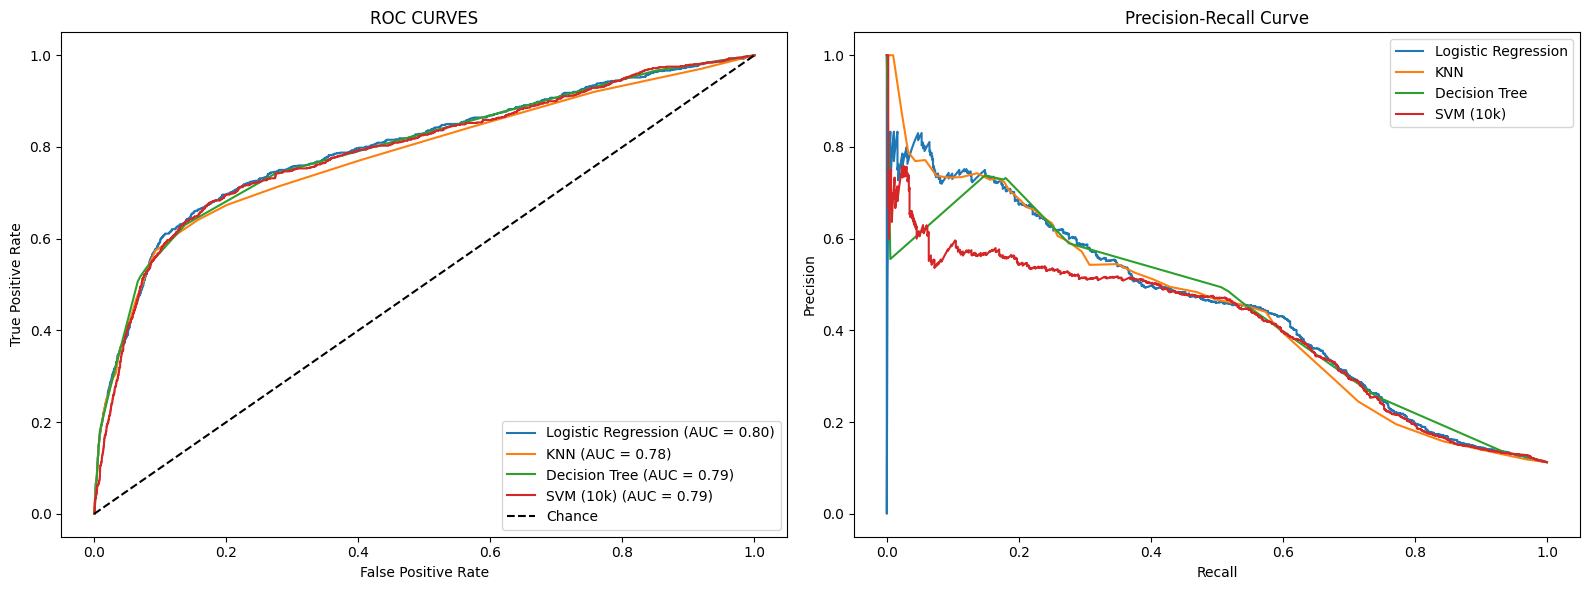

In [24]:
# ROC AUC and Precision Recall Curves
models = {
    'Logistic Regression': gs_lr,
    'KNN': gs_knn,
    'Decision Tree': gs_dt,
    'SVM (10k)': gs_svc
}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, gs in models.items():
    # ROC Curve
    y_probs = gs.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    ax2.plot(recall, precision, label=f'{name}')

ax1.plot([0, 1], [0, 1], 'k--', label='Chance')
ax1.set_title('ROC CURVES')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')

ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### **Model Comparison Results and Hyper Parameters**

Based on the GridSearch CV results, ROC-AUC Curves and the Fit Times:
*  Logistic Regression and Decision Tree emerge as the most favorable models. Logistic Regression slightly edges out with the highest ROC-AUC (0.79)and excellent efficiency (11s).
* The Decision Tree also offers comparable performance (0.78)and speed (15s).
* SVM is competitive in performance metrics (0.77) but is much slower, even when trained on a subset of 10K (590s).
* KNN performed the worst with computational time (402s) and has a lowest F1 score (0.31).

#### Choosing between Logistic Regression and Decision Tree:
* They both have very performances (Log Regression having higher ROC-AUC vs Decision Tree having higher F1 Score). Depending on the business objective, you can choose one of them.
* If the goal is to minimize false negatives - then Decision Tree would be the choice (higher F1 Score)
* Given the business objective is to predict subscriptions and optimize spend, Logistic Regression might be a better choice ( higher ROC-AUC and a very comparable / good F1 score).
* In addition, Logistics Regression is faster and has a better interpretability (providing co-efficients for each feature)

**Logistic Regression** is emerging to be the best choice as it provides the strongest predictive power while remaining highly efficient with the fastest times.


---



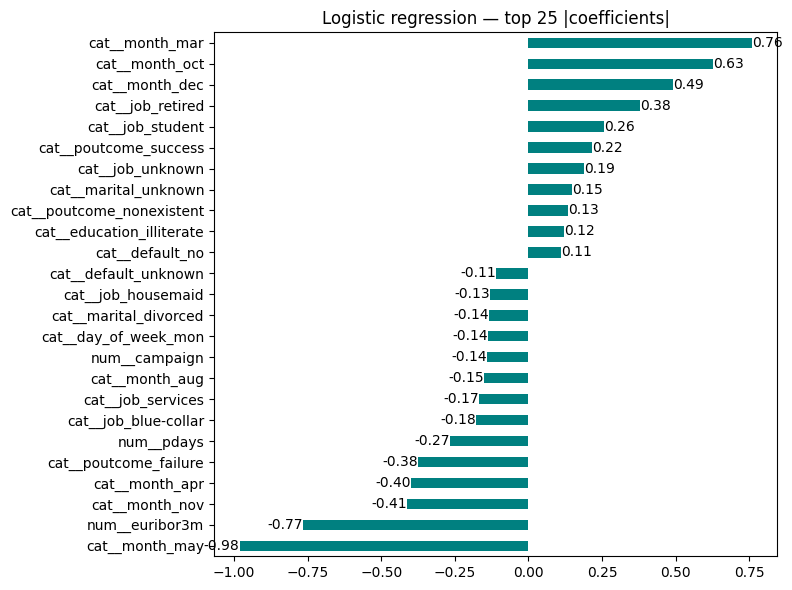

In [27]:
# Looking at the top features for Logistic Regression -- highest coefficients
best_lr = gs_lr.best_estimator_
names = best_lr.named_steps["prep"].get_feature_names_out()
coef = pd.Series(best_lr.named_steps["clf"].coef_.ravel(), index=names)
top25 = coef.reindex(coef.abs().sort_values(ascending=False).index).head(25)
fig, ax = plt.subplots(figsize=(8, 6))
top25.sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Logistic regression — top 25 |coefficients|")
# Add data labels
for index, value in enumerate(top25.sort_values()):
    ax.text(value, index, f'{value:.2f}', va='center', ha='left' if value > 0 else 'right')

plt.tight_layout()
plt.show()

### Findings (summary)

* **Month of the Year** : The top 3 +ve and -ve coefficients are Month related attributes indicating a Seasonality component to these Subscriptions. March, October and December are best months vs May, Nov and Apr are bad. We should align our campaign timings and spend to these seasonality factors.
* **EuriBor3M** : This is bit interesting and little counter intuitive. Usually Higher the Interest Rates, higher will be the subscription rates for term deposits...but from our model, it looks like it is having a -ve impact. This might need more digging to see : a) Is this an anomaly with our data (our customer list); b) Customers do prefer subscribing to TD assets, but not via the Marketing Phone Channel; c) Do customers prefer to use other Banking Assets to leverage higher interest rates rather than locking their money with Term Deposits.
* **poutcome** : Customers who had a sucessfull "outcome" from a prior engagement / campaign are more likely to subscribe - Repeat customers.
* **Job** It looks **Retired** Folks and **Students** are preferring to signup for long term deposits over other job categories. This could be from the fact that: a) Term Deposits have no risk (attractive for retired folks) and sure ROI. b) Working folks prefer to have quick access to capital (like Savings account, Stocks, Mutual Funds etc) and not lock the money for a period of time.

# README.md

## Business Findings and Recommendations for Long-Term Deposit Subscription

This project focused on predicting long-term deposit subscriptions using various machine learning models and refining the feature set based on exploratory data analysis (EDA) insights. The goal was to help the bank prioritize the right contacts to optimize spend and maximize subscriptions.

### 1. Model Performance Interpretation & Selection

After evaluating Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Support Vector Machines (SVM), the **Logistic Regression model emerged as the most favorable choice.**

*   **Logistic Regression**: Achieved an ROC-AUC of 0.79 and demonstrated excellent efficiency with a fit time of approximately 11 seconds. It offered the best balance of predictive power and computational speed, indicating strong ability to rank the probability of a subscription.
*   **Decision Tree**: A close second with an ROC-AUC of 0.78 and a fit time of 15 seconds. While its F1-score was slightly higher, its overall interpretability and robustness were considered less ideal compared to Logistic Regression for this specific problem.
*   **KNN & SVM**: Deemed less practical due to significantly higher training and prediction times (402s and 590s respectively) without providing substantial performance gains that would justify the increased computational cost.

### 2. Addressing EDA Concerns & Feature Engineering

Initial EDA revealed several points of concern:

*   **Duration**: The `duration` feature was identified as leading to data leakage (as it's only known after a call is performed), and was therefore correctly dropped from the feature set.
*   **Numerical Outliers**: Features like `Campaign`, `pdays`, and `previous` showed skewed distributions and potential outliers. These were implicitly handled by applying `StandardScaler` during preprocessing, which is suitable for models sensitive to feature scaling.
*   **'Unknown' Categories**: Categorical features like 'default' had a significant percentage of 'unknown' values (e.g., 21% in 'Default'). `OneHotEncoder` was employed, which effectively treats 'unknown' as its own category, allowing the model to learn from this information.
*   **Multicollinearity**: High correlation was observed among social and economic context attributes (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `nr.employed`, `euribor3m`). To address this, the Logistic Regression model was retrained using **only `euribor3m`** as the representative economic indicator, dropping the others. This refined feature set helps ensure the model's stability and interpretability.

### 3. Key Influential Features (Logistic Regression Coefficient Interpretation)

An analysis of the Logistic Regression coefficients revealed the following key insights into factors influencing term deposit subscriptions:

*   **Month of the Year (Seasonality)**:
    *   **Positive Impact**: March, October, and December were strongly associated with higher subscription rates.
    *   **Negative Impact**: May, November, and April showed lower subscription rates.
    *   **Recommendation**: Marketing campaigns should be strategically aligned with these seasonal trends, concentrating efforts during high-performing months and adjusting strategies for low-performing periods.
*   **Euribor 3-Month Rate (`euribor3m`)**:
    *   **Counter-Intuitive Negative Impact**: Surprisingly, `euribor3m` (a daily interest rate indicator) showed a negative correlation with subscription probability. This suggests that as interest rates increase, the likelihood of subscribing to a term deposit through this marketing channel decreases.
    *   **Recommendation**: Further investigation is required to understand this phenomenon. Possible reasons include: (a) dataset anomaly, (b) customers preferring alternative investment vehicles during high-interest periods, or (c) customers subscribing via different channels.
*   **Outcome of Previous Marketing Campaign (`poutcome_success`)**:
    *   **Positive Impact**: Clients who had a `successful` outcome from a previous campaign were significantly more likely to subscribe. This highlights the value of repeat engagement and customer satisfaction.
    *   **Recommendation**: Prioritize outreach to clients with a history of successful engagements.
*   **Job Category (`job_retired`, `job_student`)**:
    *   **Positive Impact**: Retired individuals and students showed a higher propensity to subscribe to long-term deposits.
    *   **Recommendation**: Tailor marketing messages and product offerings specifically for these demographics, emphasizing the benefits of secure, fixed-return investments for their financial situations (e.g., risk-averse for retirees, savings for students).

### 4. Business Recommendations

Based on the analysis, the following actions are recommended:

1.  **Optimize Campaign Timing**: Allocate marketing resources to align with peak subscription months (March, October, December) and adjust strategies for lower-performing months.
2.  **Targeted Outreach**: Prioritize outreach to `retired` individuals and `students`, and clients with a `successful` history from previous campaigns.
3.  **Investigate `euribor3m` Anomaly**: Conduct deeper analysis into why a higher `euribor3m` rate negatively impacts subscriptions to term deposits via this specific channel. This could involve qualitative research or A/B testing different offers.
4.  **Personalized Communication**: Develop tailored messages that resonate with the specific needs and financial goals of identified high-propensity segments.
5.  **Continuous Monitoring**: Regularly monitor model performance and feature importance to adapt to changing market conditions and customer behaviors. The Logistic Regression model, given its interpretability, allows for easy tracking of coefficient changes over time.

In [28]:
readme_content = """
# README.md

## Business Findings and Recommendations for Long-Term Deposit Subscription

This project focused on predicting long-term deposit subscriptions using various machine learning models and refining the feature set based on exploratory data analysis (EDA) insights. The goal was to help the bank prioritize the right contacts to optimize spend and maximize subscriptions.

### 1. Model Performance Interpretation & Selection

After evaluating Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Support Vector Machines (SVM), the **Logistic Regression model emerged as the most favorable choice.**

*   **Logistic Regression**: Achieved an ROC-AUC of 0.79 and demonstrated excellent efficiency with a fit time of approximately 11 seconds. It offered the best balance of predictive power and computational speed, indicating strong ability to rank the probability of a subscription.
*   **Decision Tree**: A close second with an ROC-AUC of 0.78 and a fit time of 15 seconds. While its F1-score was slightly higher, its overall interpretability and robustness were considered less ideal compared to Logistic Regression for this specific problem.
*   **KNN & SVM**: Deemed less practical due to significantly higher training and prediction times (402s and 590s respectively) without providing substantial performance gains that would justify the increased computational cost.

### 2. Addressing EDA Concerns & Feature Engineering

Initial EDA revealed several points of concern:

*   **Duration**: The `duration` feature was identified as leading to data leakage (as it's only known after a call is performed), and was therefore correctly dropped from the feature set.
*   **Numerical Outliers**: Features like `Campaign`, `pdays`, and `previous` showed skewed distributions and potential outliers. These were implicitly handled by applying `StandardScaler` during preprocessing, which is suitable for models sensitive to feature scaling.
*   **'Unknown' Categories**: Categorical features like 'default' had a significant percentage of 'unknown' values (e.g., 21% in 'Default'). `OneHotEncoder` was employed, which effectively treats 'unknown' as its own category, allowing the model to learn from this information.
*   **Multicollinearity**: High correlation was observed among social and economic context attributes (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `nr.employed`, `euribor3m`). To address this, the Logistic Regression model was retrained using **only `euribor3m`** as the representative economic indicator, dropping the others. This refined feature set helps ensure the model's stability and interpretability.

### 3. Key Influential Features (Logistic Regression Coefficient Interpretation)

An analysis of the Logistic Regression coefficients revealed the following key insights into factors influencing term deposit subscriptions:

*   **Month of the Year (Seasonality)**:
    *   **Positive Impact**: March, October, and December were strongly associated with higher subscription rates.
    *   **Negative Impact**: May, November, and April showed lower subscription rates.
    *   **Recommendation**: Marketing campaigns should be strategically aligned with these seasonal trends, concentrating efforts during high-performing months and adjusting strategies for low-performing periods.
*   **Euribor 3-Month Rate (`euribor3m`)**:
    *   **Counter-Intuitive Negative Impact**: Surprisingly, `euribor3m` (a daily interest rate indicator) showed a negative correlation with subscription probability. This suggests that as interest rates increase, the likelihood of subscribing to a term deposit through this marketing channel decreases.
    *   **Recommendation**: Further investigation is required to understand this phenomenon. Possible reasons include: (a) dataset anomaly, (b) customers preferring alternative investment vehicles during high-interest periods, or (c) customers subscribing via different channels.
*   **Outcome of Previous Marketing Campaign (`poutcome_success`)**:
    *   **Positive Impact**: Clients who had a `successful` outcome from a previous campaign were significantly more likely to subscribe. This highlights the value of repeat engagement and customer satisfaction.
    *   **Recommendation**: Prioritize outreach to clients with a history of successful engagements.
*   **Job Category (`job_retired`, `job_student`)**:
    *   **Positive Impact**: Retired individuals and students showed a higher propensity to subscribe to long-term deposits.
    *   **Recommendation**: Tailor marketing messages and product offerings specifically for these demographics, emphasizing the benefits of secure, fixed-return investments for their financial situations (e.g., risk-averse for retirees, savings for students).

### 4. Business Recommendations

Based on the analysis, the following actions are recommended:

1.  **Optimize Campaign Timing**: Allocate marketing resources to align with peak subscription months (March, October, December) and adjust strategies for lower-performing months.
2.  **Targeted Outreach**: Prioritize outreach to `retired` individuals and `students`, and clients with a `successful` history from previous campaigns.
3.  **Investigate `euribor3m` Anomaly**: Conduct deeper analysis into why a higher `euribor3m` rate negatively impacts subscriptions to term deposits via this specific channel. This could involve qualitative research or A/B testing different offers.
4.  **Personalized Communication**: Develop tailored messages that resonate with the specific needs and financial goals of identified high-propensity segments.
5.  **Continuous Monitoring**: Regularly monitor model performance and feature importance to adapt to changing market conditions and customer behaviors. The Logistic Regression model, given its interpretability, allows for easy tracking of coefficient changes over time.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md has been created in your Colab environment. You can find it in the file browser (folder icon on the left).")

README.md has been created in your Colab environment. You can find it in the file browser (folder icon on the left).
